# Thesis Notebook 12 — Final ML vs DL Comparison

**Purpose:** Present the main results section comparing CatBoost (tuned) against the Attention DL (tuned) on the
final hold-out **test** split. Both models were trained on `train+val` (417,059 samples) and evaluated exactly once
on `test` (74,573 samples) using the 4,254-feature multimodal representation.

**Key thesis claim:** CatBoost (tuned) achieves an average R² of 0.641, outperforming the best DL model (0.626) on
3 of 4 targets. The only near-tie is Valence (0.722 vs 0.721), suggesting cross-modal attention helps emotion prediction.

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

REPO = Path().resolve().parent
FIGS = REPO / 'results' / 'figures' / 'thesis'
FIGS.mkdir(parents=True, exist_ok=True)

TARGETS = ['valence', 'energy', 'danceability', 'popularity']
TARGET_LABELS = ['Valence', 'Energy', 'Danceability', 'Popularity']

# Publication-quality style
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Color palette more pastelle and publication-friendly
C_ML = '#1A80BB'   # blue — CatBoost
C_DL = '#EA801C'   # red  — Attention DL
print('Setup complete.')

Setup complete.


## 1. Load Final Test Results

In [26]:
METRICS_DIR = REPO / 'results' / 'metrics' / 'thesis_ml_test'
DL_DIR = REPO / 'results' / 'dl_metrics'

# All ML families — default hyperparams
ml_all = pd.read_csv(METRICS_DIR / 'thesis_ml_results_test_20260528_230741.csv')
# remove model Mean
ml_all = ml_all[ml_all['model'] != 'Mean']

# CatBoost tuned
ml_tuned = pd.read_csv(METRICS_DIR / 'thesis_ml_results_test_20260601_160912.csv')

# All 5 DL architectures — default
dl_all = pd.read_csv(DL_DIR / 'final_dl_test_20260601_212018.csv')

# AttentionDL tuned
dl_tuned = pd.read_csv(DL_DIR / 'final_dl_test_20260601_224941.csv')

print('ML (all families) shape:', ml_all.shape)
print('ML (CatBoost tuned) shape:', ml_tuned.shape)
print('DL (all architectures) shape:', dl_all.shape)
print('DL (AttentionDL tuned) shape:', dl_tuned.shape)

print('\nML models:', ml_all['model'].unique())
print('DL models:', dl_all['model'].unique())

ML (all families) shape: (28, 17)
ML (CatBoost tuned) shape: (4, 17)
DL (all architectures) shape: (20, 11)
DL (AttentionDL tuned) shape: (4, 11)

ML models: <StringArray>
[       'Ridge',      'XGBoost',     'LightGBM',     'CatBoost',
 'MLPRegressor',   'ExtraTrees', 'RandomForest']
Length: 7, dtype: str
DL models: <StringArray>
[                 'FlatAllMLP',         'MultiModalFusionMLP',
          'TaskGatedFusionMLP', 'AttentionTaskGatedFusionMLP',
  'TaskGatedFusionMLP_FeatEng']
Length: 5, dtype: str


In [27]:
# Build the head-to-head comparison DataFrame (finalists only)
cb_rows = ml_tuned[['target', 'r2', 'rmse', 'mae']].copy()
cb_rows.columns = ['target', 'r2_cb', 'rmse_cb', 'mae_cb']
cb_rows['target'] = cb_rows['target'].str.lower()

dl_rows = dl_tuned[['target', 'r2', 'rmse', 'mae']].copy()
dl_rows.columns = ['target', 'r2_dl', 'rmse_dl', 'mae_dl']
dl_rows['target'] = dl_rows['target'].str.lower()

comparison = pd.merge(cb_rows, dl_rows, on='target')
comparison['target'] = pd.Categorical(comparison['target'], categories=TARGETS, ordered=True)
comparison = comparison.sort_values('target').reset_index(drop=True)
comparison['target_label'] = TARGET_LABELS
comparison['winner'] = comparison.apply(
    lambda r: 'Tie' if abs(r.r2_cb - r.r2_dl) < 0.005 else ('CatBoost' if r.r2_cb > r.r2_dl else 'AttentionDL'),
    axis=1
)
comparison['margin'] = (comparison['r2_cb'] - comparison['r2_dl']).round(4)

display_cols = ['target_label', 'r2_cb', 'r2_dl', 'winner', 'margin']
display_df = comparison[display_cols].copy()
display_df.columns = ['Target', 'CatBoost_tuned R²', 'AttentionDL_tuned R²', 'Winner', 'Margin']

# Add averages row
avg_row = pd.DataFrame([['Average',
    comparison['r2_cb'].mean().round(4),
    comparison['r2_dl'].mean().round(4),
    'CatBoost', (comparison['r2_cb'].mean() - comparison['r2_dl'].mean()).round(4)]],
    columns=display_df.columns)
display_df = pd.concat([display_df, avg_row], ignore_index=True)

# Round R² columns
display_df['CatBoost_tuned R²'] = display_df['CatBoost_tuned R²'].round(4)
display_df['AttentionDL_tuned R²'] = display_df['AttentionDL_tuned R²'].round(4)

print('\n=== Final Head-to-Head: Test Split ===')
print(display_df.to_string(index=False))


=== Final Head-to-Head: Test Split ===
      Target  CatBoost_tuned R²  AttentionDL_tuned R²   Winner  Margin
     Valence             0.7220                0.7214      Tie  0.0006
      Energy             0.9212                0.9050 CatBoost  0.0162
Danceability             0.7903                0.7700 CatBoost  0.0203
  Popularity             0.1316                0.1092 CatBoost  0.0224
     Average             0.6413                0.6264 CatBoost  0.0149


## 2. Figure 1 — Per-Target R² Head-to-Head

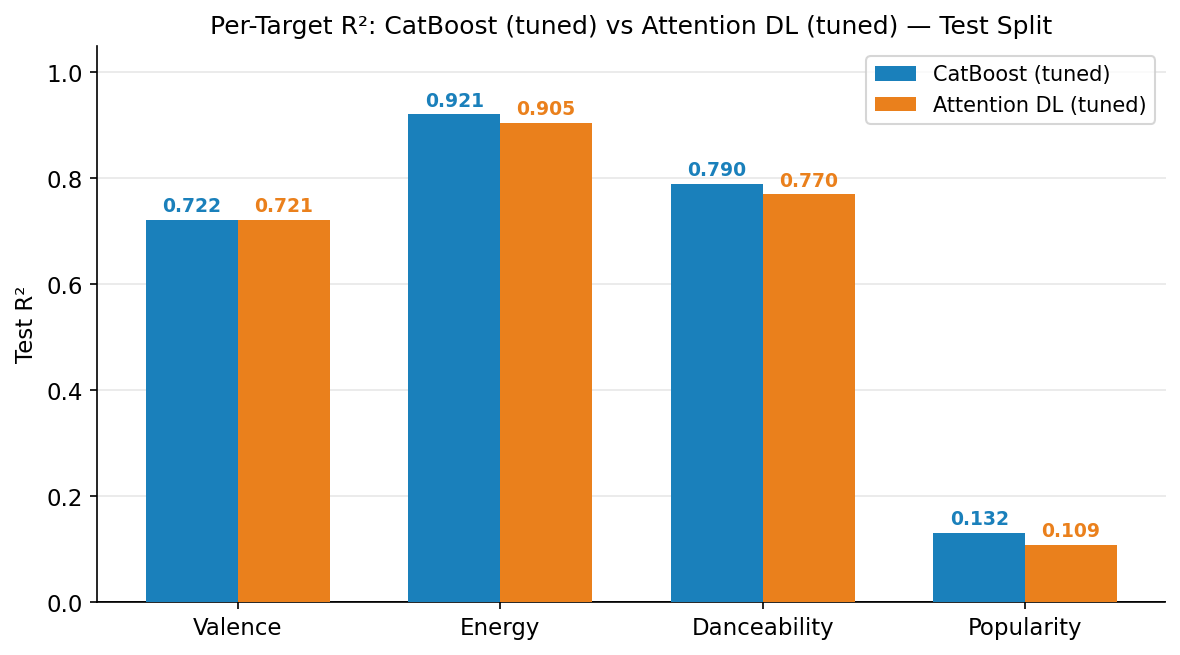

Saved: 12_ml_vs_dl_r2_by_target.png


In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(TARGETS))
w = 0.35

bars_cb = ax.bar(x - w/2, comparison['r2_cb'], w, label='CatBoost (tuned)', color=C_ML, zorder=3)
bars_dl = ax.bar(x + w/2, comparison['r2_dl'], w, label='Attention DL (tuned)', color=C_DL, zorder=3)

# Annotate bars
for bar in bars_cb:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=C_ML, fontweight='bold')
for bar in bars_dl:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=C_DL, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(TARGET_LABELS)
ax.set_ylabel('Test R²')
ax.set_title('Per-Target R²: CatBoost (tuned) vs Attention DL (tuned) — Test Split')
ax.set_ylim(0, 1.05)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(FIGS / '12_ml_vs_dl_r2_by_target.png', bbox_inches='tight')
plt.show()
print('Saved: 12_ml_vs_dl_r2_by_target.png')

## 3. Figure 2 — RMSE and MAE Comparison

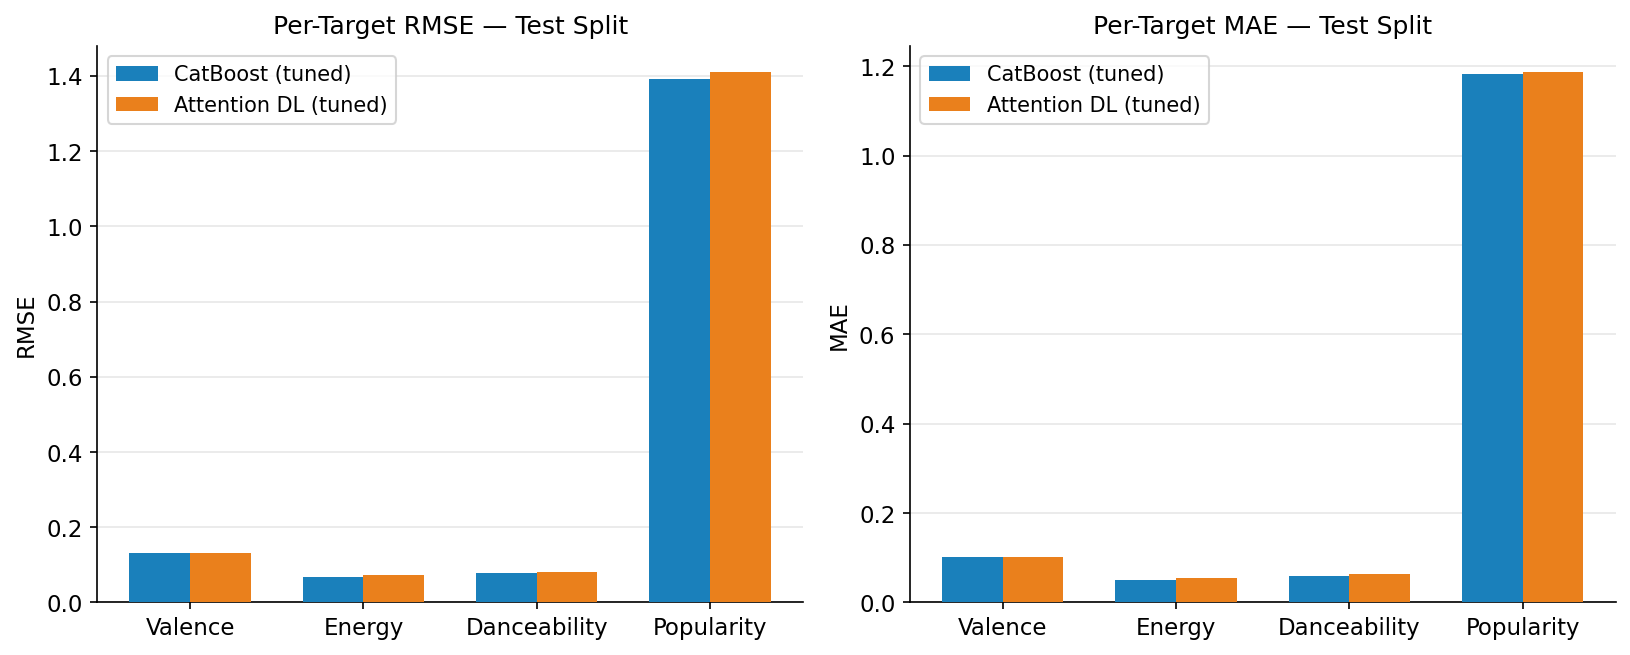

Saved: 12_ml_vs_dl_rmse_mae.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, metric, metric_label in zip(axes, ['rmse', 'mae'], ['RMSE', 'MAE']):
    cb_vals = comparison[f'{metric}_cb'].values
    dl_vals = comparison[f'{metric}_dl'].values

    x = np.arange(len(TARGETS))
    w = 0.35
    ax.bar(x - w/2, cb_vals, w, label='CatBoost (tuned)', color=C_ML, zorder=3)
    ax.bar(x + w/2, dl_vals, w, label='Attention DL (tuned)', color=C_DL, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_LABELS)
    ax.set_ylabel(metric_label)
    ax.set_title(f'Per-Target {metric_label} — Test Split')
    ax.legend()
    ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(FIGS / '12_ml_vs_dl_rmse_mae.png', bbox_inches='tight')
plt.show()
print('Saved: 12_ml_vs_dl_rmse_mae.png')

## 4. Figure 3 — Average R² Comparison (Finalists)

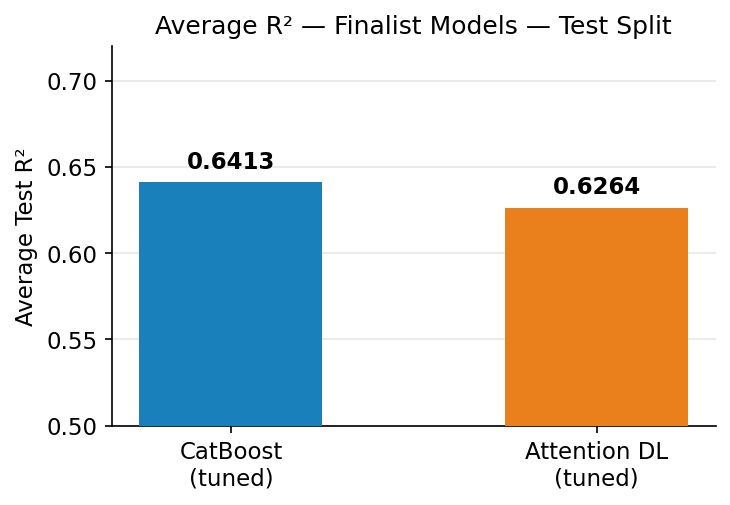

Saved: 12_avg_r2_finalists.png


In [30]:
fig, ax = plt.subplots(figsize=(5, 3.5))

models = ['CatBoost\n(tuned)', 'Attention DL\n(tuned)']
avg_r2 = [comparison['r2_cb'].mean(), comparison['r2_dl'].mean()]
colors = [C_ML, C_DL]

bars = ax.bar(models, avg_r2, color=colors, width=0.5, zorder=3)
for bar, val in zip(bars, avg_r2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Average Test R²')
ax.set_title('Average R² — Finalist Models — Test Split')
ax.set_ylim(0.5, 0.72)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(FIGS / '12_avg_r2_finalists.png', bbox_inches='tight')
plt.show()
print('Saved: 12_avg_r2_finalists.png')

## 5. Figure 4 — ML Family R² Heatmap (All 8 Families)

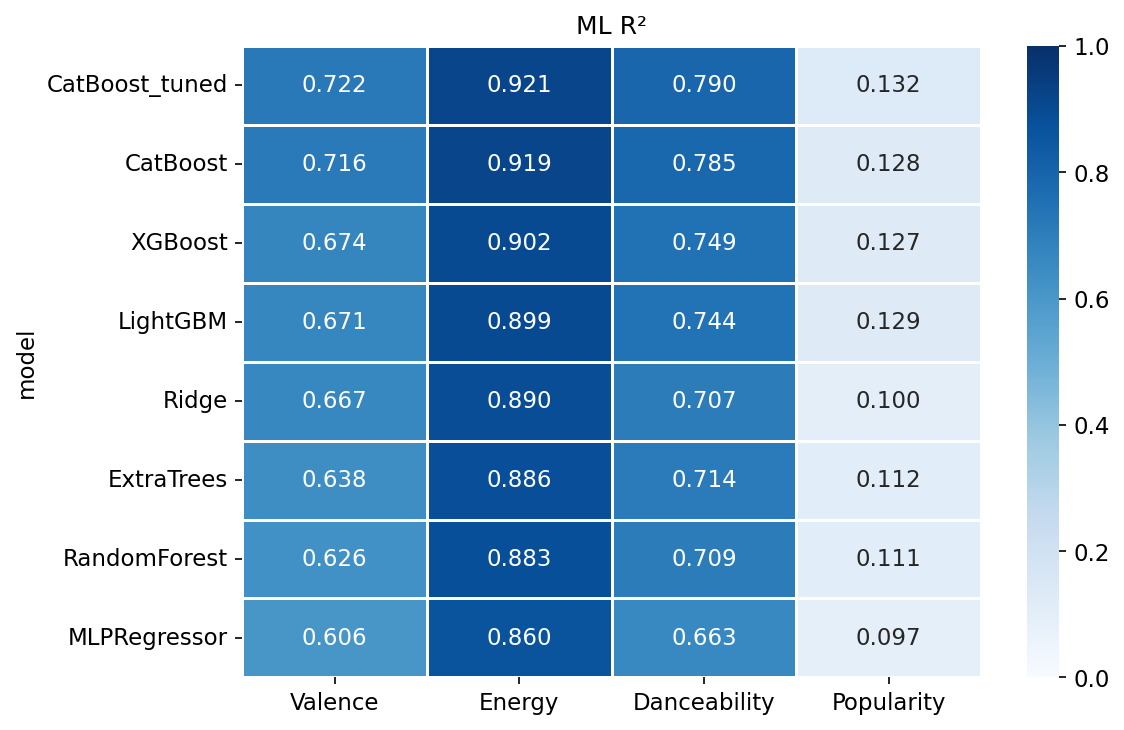

Saved: 12_ml_family_r2_heatmap.png

=== Average R² by ML Family ===
         Model  Average R²
CatBoost_tuned      0.6413
      CatBoost      0.6371
       XGBoost      0.6128
      LightGBM      0.6106
         Ridge      0.5912
    ExtraTrees      0.5874
  RandomForest      0.5821
  MLPRegressor      0.5568


In [33]:
# Combine default and tuned CatBoost into one frame
ml_combined = pd.concat([ml_all, ml_tuned], ignore_index=True)
ml_combined['target'] = ml_combined['target'].str.lower()

# Pivot for heatmap
heatmap_df = ml_combined.pivot_table(index='model', columns='target', values='r2')
# Reorder columns
heatmap_df = heatmap_df[TARGETS]
heatmap_df.columns = TARGET_LABELS
# Sort by average R²
heatmap_df['Avg'] = heatmap_df.mean(axis=1)
heatmap_df = heatmap_df.sort_values('Avg', ascending=False)
avg_col = heatmap_df.pop('Avg')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_df,
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='white',
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title('ML R²')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGS / '12_ml_family_r2_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 12_ml_family_r2_heatmap.png')

# Print average R² table
avg_r2_table = ml_combined.groupby('model')['r2'].mean().sort_values(ascending=False).reset_index()
avg_r2_table.columns = ['Model', 'Average R²']
avg_r2_table['Average R²'] = avg_r2_table['Average R²'].round(4)
print('\n=== Average R² by ML Family ===')
print(avg_r2_table.to_string(index=False))

## 6. Winner/Margin Summary Table

In [32]:
print('=== Final Head-to-Head Summary (Test Split) ===')
print(f'{"Target":<14} {"CatBoost_tuned":>14} {"AttentionDL_tuned":>18} {"Winner":>12} {"Margin":>8}')
print('-' * 70)
for _, row in comparison.iterrows():
    print(f'{row["target_label"]:<14} {row["r2_cb"]:>14.4f} {row["r2_dl"]:>18.4f} {row["winner"]:>12} {row["margin"]:>+8.4f}')
print('-' * 70)
avg_cb = comparison['r2_cb'].mean()
avg_dl = comparison['r2_dl'].mean()
print(f'{"Average":<14} {avg_cb:>14.4f} {avg_dl:>18.4f} {"CatBoost":>12} {avg_cb - avg_dl:>+8.4f}')

=== Final Head-to-Head Summary (Test Split) ===
Target         CatBoost_tuned  AttentionDL_tuned       Winner   Margin
----------------------------------------------------------------------
Valence                0.7220             0.7214          Tie  +0.0006
Energy                 0.9212             0.9050     CatBoost  +0.0162
Danceability           0.7903             0.7700     CatBoost  +0.0203
Popularity             0.1316             0.1092     CatBoost  +0.0224
----------------------------------------------------------------------
Average                0.6413             0.6264     CatBoost  +0.0149


## Summary

**Key findings from the final test evaluation:**

1. **CatBoost (tuned) wins overall** with average R² = 0.6413 vs 0.6264 for Attention DL (tuned), a margin of +0.015.
2. **CatBoost wins decisively on Energy** (R² 0.921 vs 0.905) and **Danceability** (0.790 vs 0.770).
3. **Valence is a near-tie** (0.722 vs 0.721), suggesting cross-modal attention specifically benefits emotion prediction.
4. **Popularity is the hardest target** for both systems (best R² = 0.132), driven by factors not captured in audio/lyrics.
5. Among the 8 ML families, CatBoost (tuned) ranks first, followed by CatBoost (default) — confirming that HPO adds consistent but modest value (+0.004 avg R²).